In [1]:
from cirq_sic import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [12]:
d = 3
n = d**2
phi = load_sic_fiducial(d)
sic = d*wh_povm(phi)
mu = np.ones(n)/n
P = np.array([[(sic[i]@sic[j]).trace() for j in range(n)] for i in range(n)]).real/d
Phi = (d+1)*np.eye(n) - (d/n)*np.ones((n,n))
R = np.array([[[(sic[i]@sic[j]@sic[k]).trace().real for k in range(n)] for j in range(n)] for i in range(n)])
A = np.einsum("ijk, kl->lij", R, Phi)
valid = lambda x: np.all(np.linalg.eigvals(np.einsum("ijk, i", A,  x)) >= 0)

In [13]:
def make_sum_zero_section(directions, tol=1e-12):
    """
    Convert candidate directions into an orthonormal basis lying
    in the sum-zero hyperplane.
    """
    directions = np.asarray(directions, dtype=float)
    n = directions.shape[0]
    ones = np.ones(n)

    projected = directions - np.outer(
        ones,
        np.sum(directions, axis=0) / n,
    )

    Q, R = np.linalg.qr(projected)

    if np.abs(R[0, 0]) < tol or np.abs(R[1, 1]) < tol:
        raise ValueError("The projected directions are not independent.")

    return Q[:, :len(directions)]

In [14]:
def probability_spectrahedron_section(
    A_matrices,
    x_center,
    B,
    num_angles=1000,
    tol=1e-10,
):
    """
    Ray-shoot the two-dimensional section

        x = x_center + B @ y

    of the probability spectrahedron

        x >= 0,
        sum(x) = 1,
        sum_i x_i A_i >= 0.

    Parameters
    ----------
    A_matrices:
        Array or list with shape (n, m, m), where A_matrices[i] = A_i.

    x_center:
        Interior probability vector of shape (n,).

    B:
        Section direction matrix of shape (n, 2).
        Each column should sum to zero.

    num_angles:
        Number of ray directions.

    tol:
        Numerical tolerance.

    Returns
    -------
    boundary_y:
        Boundary points in the two-dimensional y coordinates.

    boundary_x:
        Corresponding probability vectors.

    active_constraint:
        "simplex" or "PSD" for each sampled boundary point.
    """
    A = np.asarray(A_matrices, dtype=float)
    x_center = np.asarray(x_center, dtype=float)
    B = np.asarray(B, dtype=float)

    n = len(x_center)

    if A.shape[0] != n:
        raise ValueError("There must be one matrix A_i per component of x.")

    if B.shape != (n, 2):
        raise ValueError("B must have shape (n, 2).")

    if not np.isclose(np.sum(x_center), 1.0):
        raise ValueError("x_center must sum to 1.")

    if np.min(x_center) <= tol:
        raise ValueError(
            "x_center should have strictly positive entries for ray shooting."
        )

    if not np.allclose(np.sum(B, axis=0), 0.0):
        raise ValueError("Each column of B must sum to zero.")

    # Symmetrize the matrices to suppress numerical asymmetry.
    A = 0.5 * (A + np.swapaxes(A, 1, 2))

    M0 = np.einsum("i,ijk->jk", x_center, A)

    if np.min(np.linalg.eigvalsh(M0)) <= tol:
        raise ValueError(
            "A(x_center) must be positive definite for the "
            "generalized-eigenvalue formula."
        )

    angles = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)

    boundary_y = []
    boundary_x = []
    active_constraint = []

    for theta in angles:
        d = np.array([np.cos(theta), np.sin(theta)])

        # Direction in the original probability coordinates.
        v = B @ d

        # Simplex radius: first coordinate to reach zero.
        decreasing = v < -tol

        if np.any(decreasing):
            r_simplex = np.min(-x_center[decreasing] / v[decreasing])
        else:
            r_simplex = np.inf

        # PSD radius.
        Mv = np.einsum("i,ijk->jk", v, A)

        generalized_eigenvalues = eigh(
            Mv,
            M0,
            eigvals_only=True,
            check_finite=False,
        )

        lambda_min = generalized_eigenvalues[0]

        if lambda_min < -tol:
            r_psd = -1.0 / lambda_min
        else:
            r_psd = np.inf

        radius = min(r_simplex, r_psd)

        if not np.isfinite(radius):
            # This should not generally happen for a nonzero direction
            # inside the probability-normalization hyperplane.
            boundary_y.append([np.nan, np.nan])
            boundary_x.append(np.full(n, np.nan))
            active_constraint.append("unbounded")
            continue

        y_boundary = radius * d
        x_boundary = x_center + radius * v

        boundary_y.append(y_boundary)
        boundary_x.append(x_boundary)

        if r_simplex < r_psd - tol:
            active_constraint.append("simplex")
        elif r_psd < r_simplex - tol:
            active_constraint.append("PSD")
        else:
            active_constraint.append("both")

    return (
        np.asarray(boundary_y),
        np.asarray(boundary_x),
        np.asarray(active_constraint),
    )

In [15]:
def section_coordinates(
    probability_vectors,
    x_center,
    B,
    tol=1e-8,
    require_in_section=True,
):
    """
    Convert probability vectors p into intrinsic section coordinates y,
    where p = x_center + B @ y.

    Parameters
    ----------
    probability_vectors:
        A single vector of shape (n,) or an array of shape (k, n).

    x_center:
        Center of the affine section, shape (n,).

    B:
        Section basis, shape (n, section_dimension).

    tol:
        Maximum allowed reconstruction residual.

    require_in_section:
        If True, raise an error when a point does not lie in the section.

    Returns
    -------
    coordinates:
        Array of shape (k, section_dimension).

    residuals:
        Euclidean distance of each point from the affine section.
    """
    points = np.asarray(probability_vectors, dtype=float)
    x_center = np.asarray(x_center, dtype=float)
    B = np.asarray(B, dtype=float)

    single_point = points.ndim == 1
    points = np.atleast_2d(points)

    if points.shape[1] != len(x_center):
        raise ValueError("Each probability vector must have the same size as x_center.")

    # Works for both orthonormal and non-orthonormal columns of B.
    B_pinv = np.linalg.pinv(B)

    coordinates = (B_pinv @ (points - x_center).T).T
    reconstructed = x_center + coordinates @ B.T
    residuals = np.linalg.norm(points - reconstructed, axis=1)

    if require_in_section and np.any(residuals > tol):
        bad = np.flatnonzero(residuals > tol)
        raise ValueError(
            f"Points {bad.tolist()} do not lie in the section. "
            f"Residuals: {residuals[bad]}"
        )

    if single_point:
        return coordinates[0], residuals[0]

    return coordinates, residuals

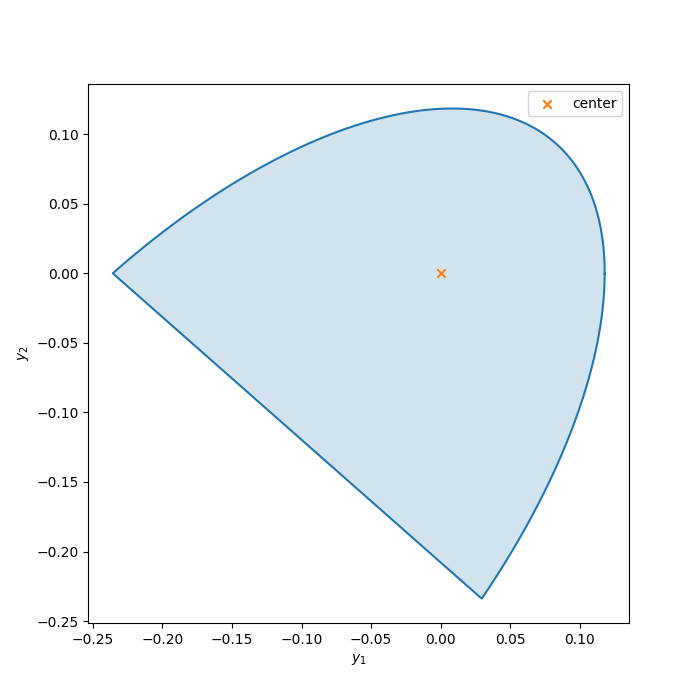

In [16]:
B = make_sum_zero_section(P[:,:2])
boundary_y, boundary_x, active = probability_spectrahedron_section(
    A_matrices=A,
    x_center=mu,
    B=B,
    num_angles=1500,
)

plt.figure(figsize=(7, 7))
plt.plot(boundary_y[:, 0], boundary_y[:, 1])
plt.fill(boundary_y[:, 0], boundary_y[:, 1], alpha=0.2)
plt.scatter([0], [0], marker="x", label="center")
plt.gca().set_aspect("equal")
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
plt.legend()
plt.show()

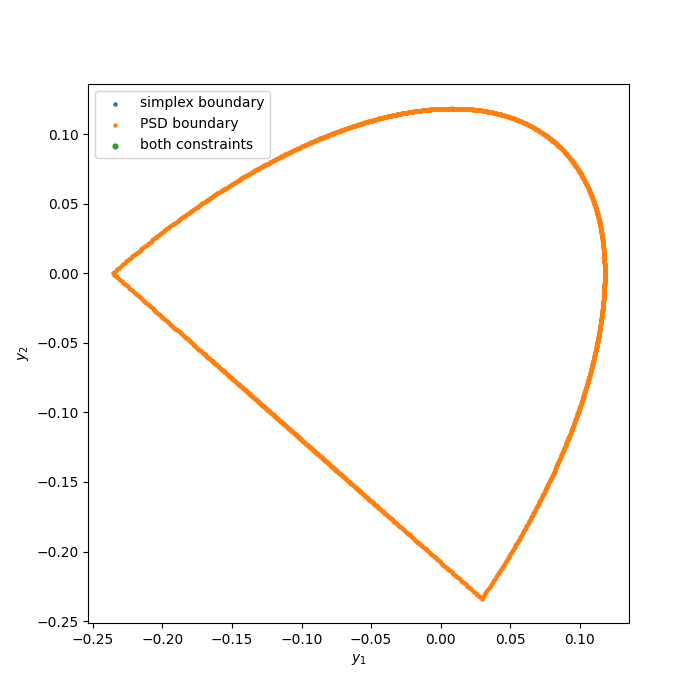

In [17]:
simplex_mask = active == "simplex"
psd_mask = active == "PSD"
both_mask = active == "both"

plt.figure(figsize=(7, 7))

plt.scatter(
    boundary_y[simplex_mask, 0],
    boundary_y[simplex_mask, 1],
    s=5,
    label="simplex boundary",
)

plt.scatter(
    boundary_y[psd_mask, 0],
    boundary_y[psd_mask, 1],
    s=5,
    label="PSD boundary",
)

plt.scatter(
    boundary_y[both_mask, 0],
    boundary_y[both_mask, 1],
    s=12,
    label="both constraints",
)

plt.gca().set_aspect("equal")
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
plt.legend()
plt.show()

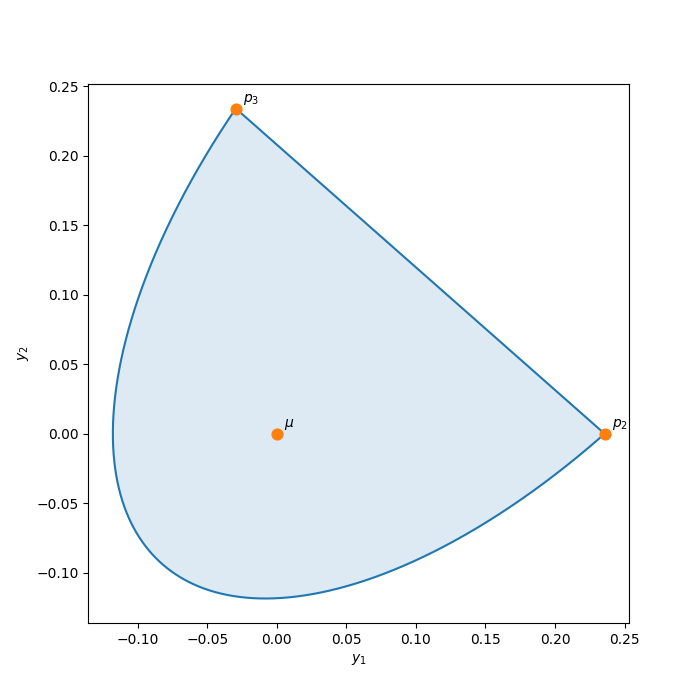

In [18]:
sic_indices = [1, 2]
marked_probabilities = [P[i] for i in sic_indices] + [mu]
B = make_sum_zero_section(np.array(marked_probabilities[:-1]).T)

boundary_y, boundary_x, active = probability_spectrahedron_section(
    A_matrices=A,
    x_center=mu,
    B=B,
    num_angles=1500,
)
marked_y, residuals = section_coordinates(
    probability_vectors=marked_probabilities,
    x_center=mu,
    B=B,  # shape (n, 2)
)

plt.figure(figsize=(7, 7))

plt.plot(
    boundary_y[:, 0],
    boundary_y[:, 1],
    #label="section boundary",
)

plt.fill(
    boundary_y[:, 0],
    boundary_y[:, 1],
    alpha=0.15,
)

plt.scatter(
    marked_y[:, 0],
    marked_y[:, 1],
    s=60,
    marker="o",
    zorder=5,
    #label="marked probability vectors",
)
labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]

for label, y in zip(labels, marked_y):
    plt.annotate(
        label,
        xy=(y[0], y[1]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.gca().set_aspect("equal")
plt.xlabel(r"$y_1$")
plt.ylabel(r"$y_2$")
#plt.legend()
plt.show()

In [19]:
import numpy as np
from scipy.linalg import eigh


def make_icosphere(subdivisions=3):
    """
    Return approximately uniform vertices on S^2 and triangular faces.
    """

    phi = (1.0 + np.sqrt(5.0)) / 2.0

    vertices = np.array([
        [-1,  phi, 0],
        [ 1,  phi, 0],
        [-1, -phi, 0],
        [ 1, -phi, 0],
        [0, -1,  phi],
        [0,  1,  phi],
        [0, -1, -phi],
        [0,  1, -phi],
        [ phi, 0, -1],
        [ phi, 0,  1],
        [-phi, 0, -1],
        [-phi, 0,  1],
    ], dtype=float)

    vertices /= np.linalg.norm(vertices, axis=1, keepdims=True)

    faces = np.array([
        [0, 11, 5],
        [0, 5, 1],
        [0, 1, 7],
        [0, 7, 10],
        [0, 10, 11],
        [1, 5, 9],
        [5, 11, 4],
        [11, 10, 2],
        [10, 7, 6],
        [7, 1, 8],
        [3, 9, 4],
        [3, 4, 2],
        [3, 2, 6],
        [3, 6, 8],
        [3, 8, 9],
        [4, 9, 5],
        [2, 4, 11],
        [6, 2, 10],
        [8, 6, 7],
        [9, 8, 1],
    ], dtype=int)

    for _ in range(subdivisions):
        midpoint_cache = {}
        new_vertices = vertices.tolist()
        new_faces = []

        def midpoint_index(i, j):
            key = tuple(sorted((i, j)))

            if key in midpoint_cache:
                return midpoint_cache[key]

            midpoint = (vertices[i] + vertices[j]) / 2.0
            midpoint /= np.linalg.norm(midpoint)

            index = len(new_vertices)
            new_vertices.append(midpoint.tolist())
            midpoint_cache[key] = index
            return index

        for i, j, k in faces:
            a = midpoint_index(i, j)
            b = midpoint_index(j, k)
            c = midpoint_index(k, i)

            new_faces.extend([
                [i, a, c],
                [j, b, a],
                [k, c, b],
                [a, b, c],
            ])

        vertices = np.asarray(new_vertices, dtype=float)
        faces = np.asarray(new_faces, dtype=int)

    return vertices, faces

def probability_spectrahedron_section_3d(
    A_matrices,
    x_center,
    B,
    subdivisions=3,
    tol=1e-10,
):
    """
    Compute a triangulated 3D cross section of

        x >= 0,
        sum(x) = 1,
        sum_i x_i A_i >= 0,

    restricted to

        x = x_center + B @ y,
        y in R^3.

    Parameters
    ----------
    A_matrices:
        Array of shape (n, m, m).

    x_center:
        Strictly positive probability vector of shape (n,).

    B:
        Matrix of shape (n, 3), whose columns sum to zero.

    subdivisions:
        Number of icosphere subdivisions.

        0 -> 12 vertices
        1 -> 42 vertices
        2 -> 162 vertices
        3 -> 642 vertices
        4 -> 2562 vertices

    Returns
    -------
    boundary_y:
        Boundary vertices in intrinsic R^3 coordinates.

    boundary_x:
        Corresponding probability vectors.

    faces:
        Triangular faces inherited from the icosphere.

    active:
        Active constraint at each vertex:
        "simplex", "PSD", or "both".
    """
    A = np.asarray(A_matrices, dtype=float)
    x_center = np.asarray(x_center, dtype=float)
    B = np.asarray(B, dtype=float)

    n = len(x_center)

    if A.shape[0] != n:
        raise ValueError("There must be one A_i for each component of x.")

    if B.shape != (n, 3):
        raise ValueError("B must have shape (n, 3).")

    if not np.isclose(np.sum(x_center), 1.0):
        raise ValueError("x_center must sum to 1.")

    if np.min(x_center) <= tol:
        raise ValueError("x_center should be strictly positive.")

    if not np.allclose(np.sum(B, axis=0), 0.0):
        raise ValueError("Each column of B must sum to zero.")

    # Numerical symmetrization.
    A = 0.5 * (A + np.swapaxes(A, 1, 2))

    M0 = np.einsum("i,ijk->jk", x_center, A)

    if np.min(np.linalg.eigvalsh(M0)) <= tol:
        raise ValueError(
            "A(x_center) must be positive definite for this formula."
        )

    directions, faces = make_icosphere(subdivisions=subdivisions)

    boundary_y = np.empty_like(directions)
    boundary_x = np.empty((len(directions), n))
    active = []

    for index, d in enumerate(directions):
        v = B @ d

        # First simplex facet reached.
        decreasing = v < -tol

        if np.any(decreasing):
            r_simplex = np.min(
                -x_center[decreasing] / v[decreasing]
            )
        else:
            r_simplex = np.inf

        # First PSD singularity reached.
        Md = np.einsum("i,ijk->jk", v, A)

        eigenvalues = eigh(
            Md,
            M0,
            eigvals_only=True,
            check_finite=False,
        )

        lambda_min = eigenvalues[0]

        if lambda_min < -tol:
            r_psd = -1.0 / lambda_min
        else:
            r_psd = np.inf

        radius = min(r_simplex, r_psd)

        if not np.isfinite(radius):
            raise RuntimeError(
                "An unbounded direction was found. This should not occur "
                "for a nonzero sum-zero direction inside the simplex."
            )

        boundary_y[index] = radius * d
        boundary_x[index] = x_center + radius * v

        scale = max(1.0, abs(r_simplex), abs(r_psd))

        if abs(r_simplex - r_psd) <= tol * scale:
            active.append("both")
        elif r_simplex < r_psd:
            active.append("simplex")
        else:
            active.append("PSD")

    return (
        boundary_y,
        boundary_x,
        faces,
        np.asarray(active),
    )

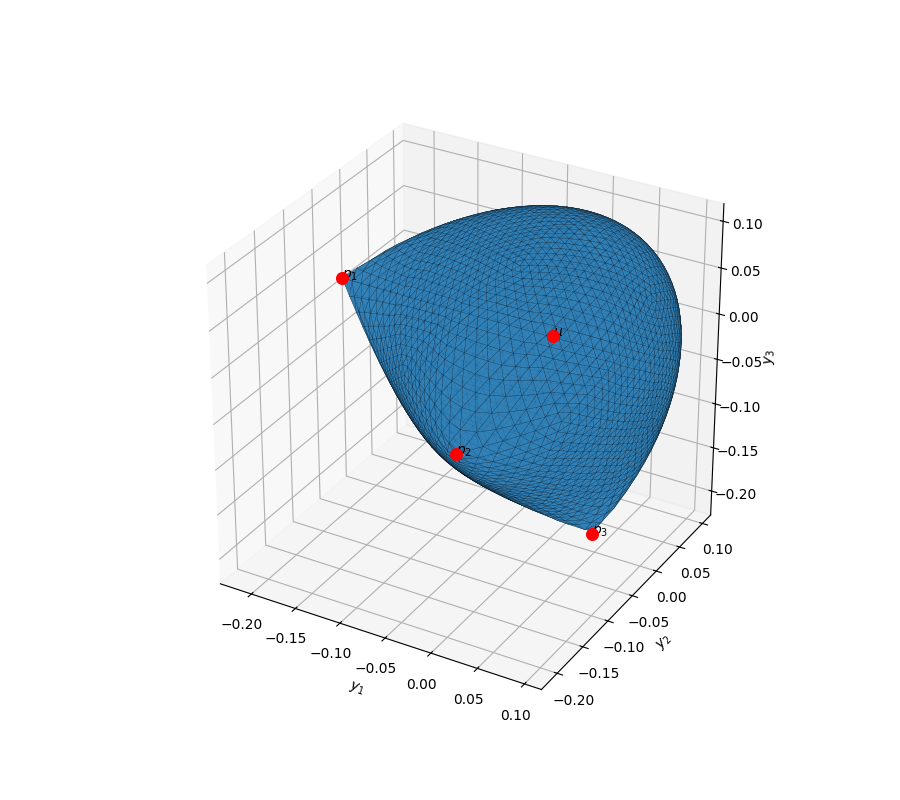

In [20]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sic_indices = [0, 1, 2]
marked_probabilities = [P[i] for i in sic_indices] + [mu]
B = make_sum_zero_section(np.array(marked_probabilities[:-1]).T)

boundary_y, boundary_x, faces, active = (
    probability_spectrahedron_section_3d(
        A_matrices=A,
        x_center=mu,
        B=B,
        subdivisions=4,
    )
)

marked_y, residuals = section_coordinates(
    probability_vectors=marked_probabilities,
    x_center=mu,
    B=B, 
)

triangles = boundary_y[faces]

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

surface = Poly3DCollection(
    triangles,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.15,
)

ax.add_collection3d(surface)

ax.scatter(
    marked_y[:, 0],
    marked_y[:, 1],
    marked_y[:, 2],
    s=70,
    marker="o",
    depthshade=False,
    color="red"
    #label="marked probability vectors",
)

labels = [r"$p_%d$" % (i+1) for i in sic_indices] + [r"$\mu$"]
for label, y in zip(labels, marked_y):
    ax.text(
        y[0],
        y[1],
        y[2],
        label,
    )

ax.set_xlim(boundary_y[:, 0].min(), boundary_y[:, 0].max())
ax.set_ylim(boundary_y[:, 1].min(), boundary_y[:, 1].max())
ax.set_zlim(boundary_y[:, 2].min(), boundary_y[:, 2].max())

ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_zlabel(r"$y_3$")

ax.set_box_aspect([
    np.ptp(boundary_y[:, 0]),
    np.ptp(boundary_y[:, 1]),
    np.ptp(boundary_y[:, 2]),
])

plt.show()

In [29]:
import plotly.graph_objects as go


fig = go.Figure(
    data=[
        go.Mesh3d(
            x=boundary_y[:, 0],
            y=boundary_y[:, 1],
            z=boundary_y[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            opacity=0.75,
        )
    ]
)

labels = ["p%d" % (i+1) for i in sic_indices] + ["mu"]
fig.add_trace(
    go.Scatter3d(
        x=marked_y[:, 0],
        y=marked_y[:, 1],
        z=marked_y[:, 2],
        mode="markers+text",
        text=labels,
        textposition="top center",
        marker=dict(size=6),
        name="marked vectors",
    )
)

fig.update_layout(
    width=1000,
    height=800,
    scene=dict(
        xaxis_title="y₁",
        yaxis_title="y₂",
        zaxis_title="y₃",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=0),
)

fig.show()

In [30]:
def mesh_edges_trace(vertices, faces, width=1):
    """
    Create a Plotly trace of the unique mesh edges.
    """
    edges = set()

    for i, j, k in faces:
        edges.add(tuple(sorted((i, j))))
        edges.add(tuple(sorted((j, k))))
        edges.add(tuple(sorted((k, i))))

    edge_x = []
    edge_y = []
    edge_z = []

    for i, j in edges:
        edge_x.extend([vertices[i, 0], vertices[j, 0], None])
        edge_y.extend([vertices[i, 1], vertices[j, 1], None])
        edge_z.extend([vertices[i, 2], vertices[j, 2], None])

    return go.Scatter3d(
        x=edge_x,
        y=edge_y,
        z=edge_z,
        mode="lines",
        line=dict(
            color="black",
            width=width,
        ),
        hoverinfo="skip",
        showlegend=False,
    )

In [34]:
fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=boundary_y[:, 0],
        y=boundary_y[:, 1],
        z=boundary_y[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        opacity=0.6,
        flatshading=True,
        name="section",
        hovertemplate=(
            "y₁=%{x:.4f}<br>"
            "y₂=%{y:.4f}<br>"
            "y₃=%{z:.4f}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    mesh_edges_trace(boundary_y, faces, width=1)
)

labels = ["p%d" % (i+1) for i in sic_indices] + ["mu"]
fig.add_trace(
    go.Scatter3d(
        x=marked_y[:, 0],
        y=marked_y[:, 1],
        z=marked_y[:, 2],
        mode="markers+text",
        text=labels,
        textposition="top center",
        marker=dict(size=6),
        name="marked vectors",
    )
)

fig.update_layout(
    width=1000,
    height=850,
    margin=dict(l=0, r=0, b=0, t=30),
    scene=dict(
        xaxis_title="y₁",
        yaxis_title="y₂",
        zaxis_title="y₃",
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.4, y=1.4, z=1.2)
        ),
    ),
)

fig.show(config={"responsive": True})